In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# create our numpy random number generator
rng = np.random.default_rng(42)

In [3]:
def plot_discrete(data, ax, colname="statistic", num_ticks=None, min_x=None, max_x=None):
    sns.histplot(data, x=colname, ax=ax)

    # keep a limited set of labeled ticks on the x-axis, evenly spaced, for legibility
    if num_ticks is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)

In [4]:
def simulate_sampling_distribution(
    underlying_distribution_simulator,  # function that simulates the underlying distribution, returning a dataframe with a column named "Outcome"
    sample_statistic,  # function that computes the sample statistic from a sample
    n_simulations=1000,
    sample_size=100,
):
    samples = [underlying_distribution_simulator(sample_size) for _ in range(n_simulations)]
    return pd.DataFrame({
        "statistic": [sample_statistic(sample) for sample in samples],
    })

## The Relationship Between Sample Size and Variance (of the Sampling Distribution)

If we flip a coin 10 times, we won't be surprised if we don't get exactly five heads and five tails. Maybe we get 7 and 3.

But if we flip the coin 10,000 times, we'll be pretty surprised if we get 70% heads.

Or, to put it in the context of voter polling, if we take a poll of 10 people and 7 say they prefer candidate A, we won't be very surprised if election day comes and candidate A gets only 45% of the vote.

But if we took a poll with a random sample of 10,000 voters, and 70% say they prefer candidate A, we will be pretty surprised by an outcome of A losing.

So, what's going on? As usual, let's use python code and our sampling framework to help build up our intuitions.


In [5]:
def draw_bernoulli(p, n):
    draws = rng.choice([0,1], size=n, p = [1-p, p])
    # Create a pandas DataFrame
    return pd.DataFrame(draws, columns=["Outcome"])

In [6]:
# draw from sampling distribution with p=.7 and different sample sizes
small, medium, large = [
    simulate_sampling_distribution(
        underlying_distribution_simulator=lambda n: draw_bernoulli(0.7, n),
        sample_statistic=lambda df: df["Outcome"].mean(),
        n_simulations=10000,
        sample_size=n,
    )
    for n in [10, 100, 10000]
]

In [7]:
small

,statistic
0,0.8
1,0.8
2,0.7
3,0.7
4,0.8
...,...
9995,0.8
9996,0.6
9997,0.8
9998,0.6


In [8]:
small.value_counts(normalize=True).sort_index()

statistic
0.1          0.0001
0.2          0.0012
0.3          0.0096
0.4          0.0376
0.5          0.1018
0.6          0.1976
0.7          0.2654
0.8          0.2347
0.9          0.1252
1.0          0.0268
Name: proportion, dtype: float64

In [9]:
medium.value_counts(normalize=True).sort_index()

statistic
0.54         0.0004
0.55         0.0008
0.56         0.0012
0.57         0.0022
0.58         0.0040
0.59         0.0047
0.60         0.0070
0.61         0.0127
0.62         0.0176
0.63         0.0271
0.64         0.0363
0.65         0.0457
0.66         0.0587
0.67         0.0658
0.68         0.0808
0.69         0.0855
0.70         0.0872
0.71         0.0839
0.72         0.0820
0.73         0.0733
0.74         0.0647
0.75         0.0464
0.76         0.0404
0.77         0.0255
0.78         0.0205
0.79         0.0113
0.80         0.0066
0.81         0.0039
0.82         0.0021
0.83         0.0005
0.84         0.0008
0.85         0.0002
0.86         0.0002
Name: proportion, dtype: float64

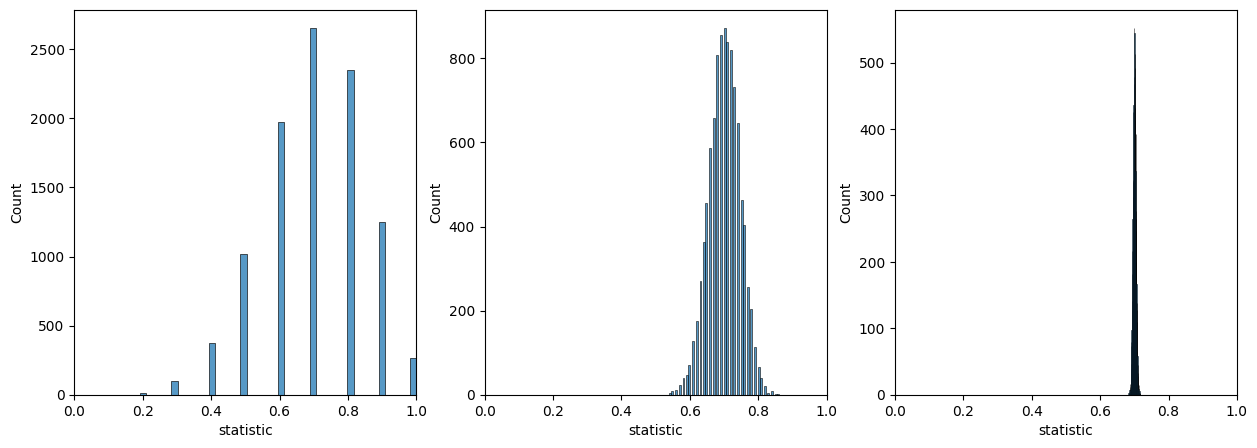

In [10]:
# make a figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# plot the bar plot on each subplot
plot_discrete(small, ax1, min_x=0, max_x=1)
plot_discrete(medium, ax2, min_x=0, max_x=1)
plot_discrete(large, ax3, min_x=0, max_x=1)

In [11]:
# compute the variance of the sampling distributions
small["statistic"].var(), medium["statistic"].var(), large["statistic"].var()

(0.021072684768476853, 0.002057835734573457, 2.048319234633463e-05)

## Law of Large Numbers
This code demonstrates the concept of the Law of Large Numbers, which states that:
- the sampling distribution of the mean has the same mean as the underlying distribution's mean
- as the *size of a sample* from a population increases, the variance goes down. That is, the mean value of the sample will tend to be closer to the mean value of the population. 

In the context of voter polling, this means that as you poll more and more voters, your estimate of the proportion of voters who will vote for a particular candidate will become more accurate.

The law of large numbers means the analogous statement is also true for samples from any other distribution.

In [12]:
# do the analogous thing for samples from a poisson distribution
def sample_poisson(lam=1, n=1000):
    data = rng.poisson(lam=lam, size=n)
    return pd.DataFrame(data, columns=["Outcome"])

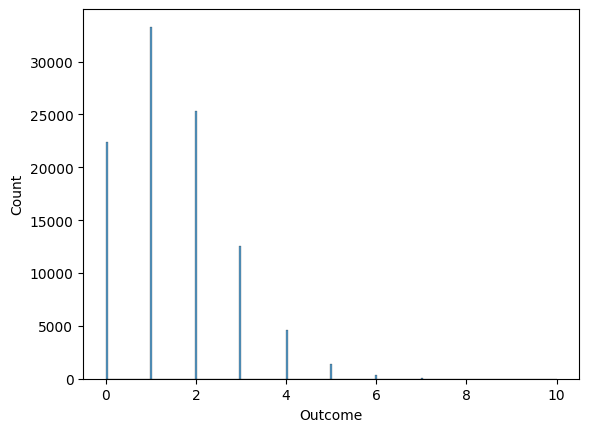

In [13]:
plot_discrete(sample_poisson(lam=1.5, n=100000), plt.gca(), colname="Outcome")

In [14]:
# package up the demonstration of the impact of sample size into a function, so we don't repeat ourselves
def show_effect_of_sample_size(
    sample_sizes, sample_statistic, underlying_distribution_simulator, n_simulations=1000
):
    # simulate sampling distributions for each sample size
    sampling_distributions = [
        simulate_sampling_distribution(
            underlying_distribution_simulator=underlying_distribution_simulator,
            sample_statistic=sample_statistic,
            n_simulations=n_simulations,
            sample_size=n,
        )
        for n in sample_sizes
    ]

    # make a figure with a subplot for each sample size
    fig, axes = plt.subplots(1, len(sample_sizes), figsize=(5 * len(sample_sizes), 5))

    # plot the bar plot on each subplot
    for ax, sampling_distribution, sample_size in zip(
        axes, sampling_distributions, sample_sizes
    ):
        plot_discrete(sampling_distribution, ax, num_ticks=6, min_x=0, max_x=4)
        ax.set_title(f"Sample size = {sample_size}")

    # compute the variance of the sampling distributions
    return [
        sampling_distribution["statistic"].var()
        for sampling_distribution in sampling_distributions
    ]

[0.14906198459845985, 0.014846993723372337, 0.001519146267866786]

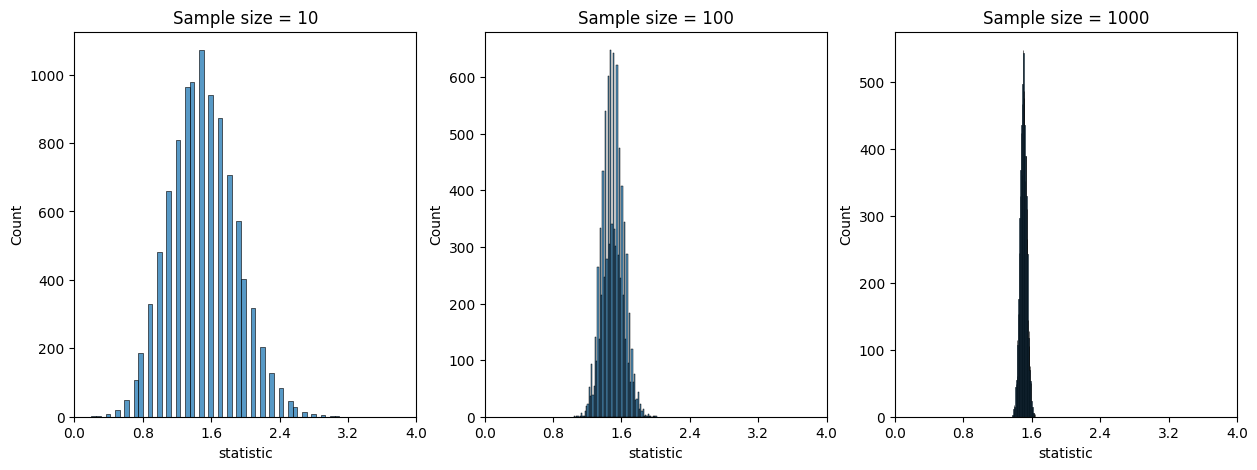

In [15]:
show_effect_of_sample_size(
    sample_sizes=[10, 100, 1000],
    sample_statistic=lambda df: df["Outcome"].mean(),
    underlying_distribution_simulator=lambda n: sample_poisson(lam=1.5, n=n),
    n_simulations=10000,
)